<a href="https://colab.research.google.com/github/TetianaMar-888/My_projects/blob/main/Bank_Dataset_Machine_Learning_Project_english.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>



##**Main Task**
Build a model to predict whether a bank client will subscribe to a term deposit. Explain to the client how the model works and why it makes specific decisions.

**Dataset and ML Task**
The data relates to direct marketing campaigns (phone calls) of a Portuguese banking institution. The final classification goal is to predict whether a client will subscribe to a term deposit.

**Bank Client Data:**
- `age` – client's age (numerical variable)
- `job` – type of employment (categorical: admin., blue-collar, entrepreneur, housemaid, management, retired, self-employed, services, student, technician, unemployed, unknown)
- `marital` – marital status (categorical: divorced, married, single, unknown; note: divorced includes widowed)
- `education` – education level (categorical: basic.4y, basic.6y, basic.9y, high.school, illiterate, professional.course, university.degree, unknown)
- `default` – has the client defaulted on credit? (categorical: no, yes, unknown)
- `housing` – does the client have a mortgage? (categorical: no, yes, unknown)
- `loan` – does the client have a personal loan? (categorical: no, yes, unknown)

**Last Contact Data (Current Campaign):**
- `contact` – contact communication type (categorical: cellular, telephone)
- `month` – last contact month (categorical: jan, feb, mar, …, nov, dec)
- `day_of_week` – last contact day of week (categorical: mon, tue, wed, thu, fri)
- `duration` – last contact duration in seconds (numerical)

> ⚠️ **Important note:** this variable strongly influences the target variable (e.g. if duration = 0, then y = no). However, the duration is unknown before the call is made. Furthermore, after the call ends, the value of y is already known.

**Other Attributes:**
- `campaign` – number of contacts during this campaign for this client (numerical, includes last contact)
- `pdays` – number of days since the client was last contacted in a previous campaign (numerical; 999 means client was not previously contacted)
- `previous` – number of contacts before this campaign for this client (numerical)
- `poutcome` – outcome of the previous campaign (categorical: failure, nonexistent, success)

**Socioeconomic Context Attributes:**
- `emp.var.rate` – employment variation rate (quarterly indicator, numerical)
- `cons.price.idx` – consumer price index (monthly indicator, numerical)
- `cons.conf.idx` – consumer confidence index (monthly indicator, numerical)
- `euribor3m` – Euribor 3-month rate (daily indicator, numerical)
- `nr.employed` – number of employees (quarterly indicator, numerical)

**Target Variable:**
- `y` – has the client subscribed to a term deposit? (binary: yes, no)

---

**What We Will Do**

1. Conduct **Exploratory Data Analysis (EDA)** and formulate hypotheses about the influence of individual features on the target variable `y`

2. Describe which methods we consider appropriate and select **model evaluation metrics**

3. Perform **data preprocessing** before passing data to the model

4. Train **multiple machine learning models**

5. Analyze **feature importance** for the best-performing model from a common sense perspective

6. For the best model, conduct **SHAP analysis** to explain feature influence on predictions

7. Analyze **records where the model makes errors** and suggest how to improve the solution to avoid these mistakes


In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler, LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report,
                              roc_auc_score,
                              f1_score,
                              precision_score,
                              recall_score,
                              confusion_matrix)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from typing import Tuple, Dict, Any
from xgboost import XGBClassifier
from hyperopt import fmin, tpe, hp, STATUS_OK, Trials
from sklearn.model_selection import cross_val_score
import shap


pd.set_option('display.max.rows',150)
pd.set_option('display.max.columns',150)
pd.set_option('float_format', '{:.2f}'.format)

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


#Exploratory Data Analysis

In [3]:
df = pd.read_csv("drive/MyDrive/Colab Notebooks/bank-additional-full.csv", sep=';')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

No missing values. Memory usage is low.

In [4]:
df

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,261,1,999,0,nonexistent,1.10,93.99,-36.40,4.86,5191.00,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,149,1,999,0,nonexistent,1.10,93.99,-36.40,4.86,5191.00,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,226,1,999,0,nonexistent,1.10,93.99,-36.40,4.86,5191.00,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,151,1,999,0,nonexistent,1.10,93.99,-36.40,4.86,5191.00,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,307,1,999,0,nonexistent,1.10,93.99,-36.40,4.86,5191.00,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41183,73,retired,married,professional.course,no,yes,no,cellular,nov,fri,334,1,999,0,nonexistent,-1.10,94.77,-50.80,1.03,4963.60,yes
41184,46,blue-collar,married,professional.course,no,no,no,cellular,nov,fri,383,1,999,0,nonexistent,-1.10,94.77,-50.80,1.03,4963.60,no
41185,56,retired,married,university.degree,no,yes,no,cellular,nov,fri,189,2,999,0,nonexistent,-1.10,94.77,-50.80,1.03,4963.60,no
41186,44,technician,married,professional.course,no,no,no,cellular,nov,fri,442,1,999,0,nonexistent,-1.10,94.77,-50.80,1.03,4963.60,yes


In [5]:
print("\n Our target variable 'y'")
print(df['y'].value_counts()) #The target variable is 'y' — whether the client subscribed to a term deposit
print("\n Statistical report for numerical variables")
print(df.describe()) #Statistical report for numerical variables
print("\n Names of categorical variables")
print(df.select_dtypes(include = "object").columns) #Names of categorical variables
print("\n Number of categorical variables")
print(len(df.select_dtypes(include = "object").columns)) #Number of categorical variables
print(df.shape)


 Our target variable 'y'
y
no     36548
yes     4640
Name: count, dtype: int64

 Statistical report for numerical variables
           age  duration  campaign    pdays  previous  emp.var.rate  \
count 41188.00  41188.00  41188.00 41188.00  41188.00      41188.00   
mean     40.02    258.29      2.57   962.48      0.17          0.08   
std      10.42    259.28      2.77   186.91      0.49          1.57   
min      17.00      0.00      1.00     0.00      0.00         -3.40   
25%      32.00    102.00      1.00   999.00      0.00         -1.80   
50%      38.00    180.00      2.00   999.00      0.00          1.10   
75%      47.00    319.00      3.00   999.00      0.00          1.40   
max      98.00   4918.00     56.00   999.00      7.00          1.40   

       cons.price.idx  cons.conf.idx  euribor3m  nr.employed  
count        41188.00       41188.00   41188.00     41188.00  
mean            93.58         -40.50       3.62      5167.04  
std              0.58           4.63       1.7

In [6]:
print("\n Categorical variable names containing unknown")
unknown_cols = ['job', 'marital', 'education', 'default', 'housing', 'loan']
for col in unknown_cols:
    count = (df[col] == 'unknown').sum()
    pct = count / len(df) * 100
    print(f"{col:12}: {count:5} ({pct:.2f}%)")


 Categorical variable names containing unknown
job         :   330 (0.80%)
marital     :    80 (0.19%)
education   :  1731 (4.20%)
default     :  8597 (20.87%)
housing     :   990 (2.40%)
loan        :   990 (2.40%)


Observation

There is an imbalance of classes in the target variable.
The attribute pdays max=999 - means that almost all customers are new and have not had contact with the bank since the last campaign.
The duration column will need to be removed before data distribution.
Categorical columns containing unknown (job, marital, education, default, housing, loan) - will need to be replaced with the mode or median.

In my opinion, the categories that affect deposit placement are: education, employment, age and economic indicators.

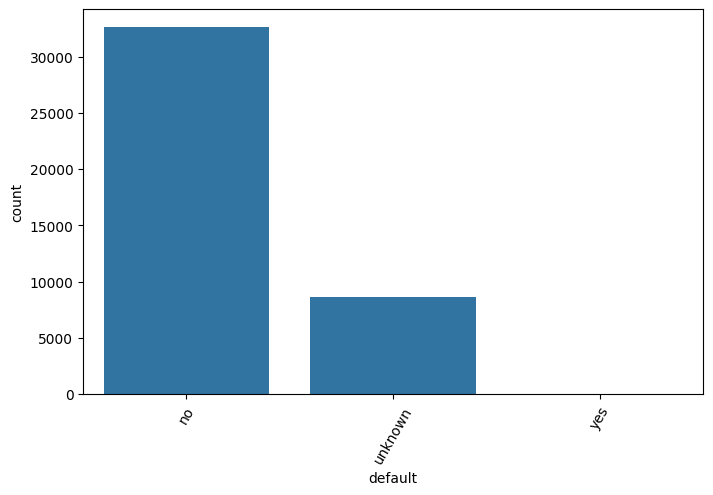

In [7]:
# Visualize the column for whether there are any overdue loans
plt.figure(figsize = (8,5))
sns.countplot(data = df, x = "default")
plt.xticks(rotation = 60)
plt.show()

In [8]:
df.default.value_counts()

,count
default,
no,32588
unknown,8597
yes,3


In [9]:
df.default.mode()[0]

'no'

#Preprocessing

In [10]:
numeric_cols = df.select_dtypes(include = np.number).columns.tolist()
print(numeric_cols)
categorical_cols = df.select_dtypes(include = 'object').columns.tolist()
print(categorical_cols)

['age', 'duration', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']
['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome', 'y']


Observation

default fill with mode, or delete the column altogether.

I decide to leave the default column, as it is important, in my opinion, for the forecast. Because it shows that people do not have overdue loans. And, this is an important component for placing a deposit. And, unknown means that this information has not been verified for these clients.

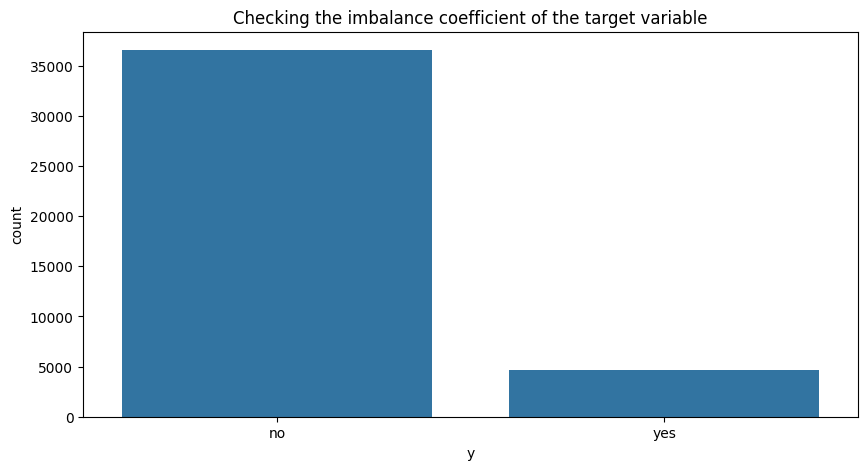

In [11]:
plt.figure(figsize = (10,5))
sns.countplot(x = df['y'], data = df)
plt.title('Checking the imbalance coefficient of the target variable')
plt.show()

In [12]:
#Replace 'unknown' with NaN and fill with mode
fill_cols = ['job', 'marital', 'education', 'housing', 'loan']
df[fill_cols] = df[fill_cols].replace('unknown', np.nan)

for col in fill_cols:
    df[col] = df[col].fillna(df[col].mode()[0])
print(df[fill_cols].isin(['unknown']).sum())

job          0
marital      0
education    0
housing      0
loan         0
dtype: int64


In [13]:
#I keep the duration column separately and remove it from the general dataset
duration_series = df['duration'].copy()
df = df.drop(columns=['duration'])

In [27]:
duration_test = duration_series.iloc[X_test.index]
print("duration_test created:", duration_test.shape)

duration_test created: (12357,)


In [15]:
#Checking for Outliers
num_cols = ['age', 'campaign', 'previous', 'emp.var.rate',
            'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']

# Method IQR
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = df[(df[col] < Q1 - 1.5 * IQR) | (df[col] > Q3 + 1.5 * IQR)]
    print(f"{col:20}: {len(outliers):5} outliers ({len(outliers)/len(df)*100:.1f}%)")

age                 :   469 outliers (1.1%)
campaign            :  2406 outliers (5.8%)
previous            :  5625 outliers (13.7%)
emp.var.rate        :     0 outliers (0.0%)
cons.price.idx      :     0 outliers (0.0%)
cons.conf.idx       :   447 outliers (1.1%)
euribor3m           :     0 outliers (0.0%)
nr.employed         :     0 outliers (0.0%)


Observation:

No need to remove outliers - all values ​​make real economic or business sense.

In [17]:
#column pdays I replace with the column "have you contacted at all (was_contacted)". Because almost 96% of clients have not contacted the bank before
df['was_contacted'] = (df['pdays'] != 999).astype(int)

In [18]:
# Encode the target variable
df['y'] = (df['y'] == 'yes').astype(int)
print(df['y'].value_counts())

y
0    36548
1     4640
Name: count, dtype: int64


In [39]:
df[categorical_cols].nunique()

,0
job,11
marital,3
education,7
default,3
housing,2
loan,2
contact,2
month,10
day_of_week,5
poutcome,3


In [19]:
# One-Hot Encoding
cat_cols = df.select_dtypes(include='object').columns.tolist()
print("Categorical columns:", cat_cols)

df = pd.get_dummies(df, columns=cat_cols, drop_first=True)
print(df.shape)

Categorical columns: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome']
(41188, 49)


In [20]:
#Split the data
train_val_df, test_df = train_test_split(df, test_size=0.3, random_state=42, stratify=df['y'])
train_df, val_df = train_test_split(train_val_df, test_size=0.25, random_state=42, stratify=train_val_df['y'])

print('train_df.shape :', train_df.shape)
print('val_df.shape   :', val_df.shape)
print('test_df.shape  :', test_df.shape)

train_df.shape : (21623, 49)
val_df.shape   : (7208, 49)
test_df.shape  : (12357, 49)


In [22]:
# Checking the balance of classes in each sample
print("\nClass balance:")
print("Train:", train_df['y'].value_counts(normalize=True).round(3))
print("Val:  ", val_df['y'].value_counts(normalize=True).round(3))
print("Test: ", test_df['y'].value_counts(normalize=True).round(3))


Class balance:
Train: y
0   0.89
1   0.11
Name: proportion, dtype: float64
Val:   y
0   0.89
1   0.11
Name: proportion, dtype: float64
Test:  y
0   0.89
1   0.11
Name: proportion, dtype: float64


In [23]:
#define X and y
X_train = train_df.drop(columns=['y'])
y_train = train_df['y']

X_val = val_df.drop(columns=['y'])
y_val = val_df['y']

X_test = test_df.drop(columns=['y'])
y_test = test_df['y']

print(X_train.shape, X_val.shape, X_test.shape)

(21623, 48) (7208, 48) (12357, 48)


In [24]:
# SMOTE only on train
sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

print("Before SMOTE:  ", y_train.value_counts())
print("After SMOTE:", y_train_res.value_counts())
print("New form of X_train_res:", X_train_res.shape)

Before SMOTE:   y
0    19187
1     2436
Name: count, dtype: int64
After SMOTE: y
0    19187
1    19187
Name: count, dtype: int64
New form of X_train_res: (38374, 48)


In [25]:
scaler = StandardScaler()

# fit only on train after SMOTE
X_train_scaled = scaler.fit_transform(X_train_res)
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test)

print("X_train_scaled:", X_train_scaled.shape)
print("X_val_scaled:  ", X_val_scaled.shape)
print("X_test_scaled: ", X_test_scaled.shape)

X_train_scaled: (38374, 48)
X_val_scaled:   (7208, 48)
X_test_scaled:  (12357, 48)


In [28]:
path = '/content/drive/MyDrive/Colab Notebooks/data/'
os.makedirs(path, exist_ok=True)

# Scaled data (for LR and kNN)
pd.DataFrame(X_train_scaled, columns=X_train.columns).to_parquet(path + 'X_train_scaled.parquet')
pd.DataFrame(X_val_scaled,   columns=X_val.columns).to_parquet(path + 'X_val_scaled.parquet')
pd.DataFrame(X_test_scaled,  columns=X_test.columns).to_parquet(path + 'X_test_scaled.parquet')

# Not scaled data (for DT and XGBoost)
X_train_res.to_parquet(path + 'X_train_res.parquet')
X_val.to_parquet(path + 'X_val.parquet')
X_test.to_parquet(path + 'X_test.parquet')

# Targets
y_train_res.to_frame().to_parquet(path + 'y_train_res.parquet')
y_val.to_frame().to_parquet(path + 'y_val.parquet')
y_test.to_frame().to_parquet(path + 'y_test.parquet')

# Duration for analysis
duration_test.to_frame().to_parquet(path + 'duration_test.parquet')

print("Files saved:")
for f in sorted(os.listdir(path)):
    print(f"  ✅ {f}")

Files saved:
  ✅ X_test.parquet
  ✅ X_test_scaled.parquet
  ✅ X_train_res.parquet
  ✅ X_train_scaled.parquet
  ✅ X_val.parquet
  ✅ X_val_scaled.parquet
  ✅ duration_test.parquet
  ✅ y_test.parquet
  ✅ y_train_res.parquet
  ✅ y_val.parquet


To evaluate the models, I use multiple metrics to obtain a more reliable and unbiased assessment due to class imbalance.

ROC-AUC — measures the overall ability of the model to distinguish between classes, but does not reflect performance at a specific threshold.
F1-score — balances Precision and Recall, which is especially important in imbalanced datasets (as in this case).

In banking marketing, Recall is typically more important: it is better to contact a few extra clients than to miss a potential customer who is likely to subscribe to a deposit.

Therefore, the evaluation focuses on these metrics.

In [29]:
path = '/content/drive/MyDrive/Colab Notebooks/data/'

# Scaled data (for LR and kNN)
X_train_scaled = pd.read_parquet(path + 'X_train_scaled.parquet').values
X_val_scaled   = pd.read_parquet(path + 'X_val_scaled.parquet').values
X_test_scaled  = pd.read_parquet(path + 'X_test_scaled.parquet').values

# Not scaled data (for DT and XGBoost)
X_train_res = pd.read_parquet(path + 'X_train_res.parquet')
X_val       = pd.read_parquet(path + 'X_val.parquet')
X_test      = pd.read_parquet(path + 'X_test.parquet')

# Targets
y_train_res = pd.read_parquet(path + 'y_train_res.parquet')['y']
y_val       = pd.read_parquet(path + 'y_val.parquet')['y']
y_test      = pd.read_parquet(path + 'y_test.parquet')['y']

# Duration for analysis
duration_test = pd.read_parquet(path + 'duration_test.parquet')['duration']

print("Data loaded!")
print(f"X_train_scaled: {X_train_scaled.shape}")
print(f"X_val_scaled:   {X_val_scaled.shape}")
print(f"X_test_scaled:  {X_test_scaled.shape}")

Data loaded!
X_train_scaled: (38374, 48)
X_val_scaled:   (7208, 48)
X_test_scaled:  (12357, 48)


In [30]:
#I bring it to the model evaluation function for ease of checking and further comparison of models
def evaluate_model(model_name, y_true, y_pred, y_proba):
    print("=" * 40)
    print(f"  {model_name}")
    print("=" * 40)
    print(f"ROC-AUC  : {roc_auc_score(y_true, y_proba):.4f}")
    print(f"F1-Score : {f1_score(y_true, y_pred):.4f}")
    print(f"Precision: {precision_score(y_true, y_pred):.4f}")
    print(f"Recall   : {recall_score(y_true, y_pred):.4f}")
    print(f"\n{classification_report(y_true, y_pred)}")
    print(f"Confusion Matrix:\n{confusion_matrix(y_true, y_pred)}")

#Training the Logistic Regression model

In [31]:
lr = LogisticRegression(random_state=42, max_iter=1000)
lr.fit(X_train_scaled, y_train_res)

y_val_pred = lr.predict(X_val_scaled)
y_val_proba = lr.predict_proba(X_val_scaled)[:, 1]

evaluate_model("Logistic Regression — Validation", y_val, y_val_pred, y_val_proba)

  Logistic Regression — Validation
ROC-AUC  : 0.7094
F1-Score : 0.3642
Precision: 0.3284
Recall   : 0.4089

              precision    recall  f1-score   support

           0       0.92      0.89      0.91      6396
           1       0.33      0.41      0.36       812

    accuracy                           0.84      7208
   macro avg       0.63      0.65      0.64      7208
weighted avg       0.86      0.84      0.85      7208

Confusion Matrix:
[[5717  679]
 [ 480  332]]


Observations

Model is too conservative — says "no" more often
Recall = 0.41 — misses 59% of potential customers
Precision = 0.33 — out of every 3 predicted "yes" — 2 are false

#Training the kNN model

In [32]:
knn = KNeighborsClassifier(n_neighbors=7)
knn.fit(X_train_scaled, y_train_res)

y_val_pred_knn  = knn.predict(X_val_scaled)
y_val_proba_knn = knn.predict_proba(X_val_scaled)[:, 1]

evaluate_model("kNN — Validation", y_val, y_val_pred_knn, y_val_proba_knn)

  kNN — Validation
ROC-AUC  : 0.7246
F1-Score : 0.3691
Precision: 0.3113
Recall   : 0.4532

              precision    recall  f1-score   support

           0       0.93      0.87      0.90      6396
           1       0.31      0.45      0.37       812

    accuracy                           0.83      7208
   macro avg       0.62      0.66      0.63      7208
weighted avg       0.86      0.83      0.84      7208

Confusion Matrix:
[[5582  814]
 [ 444  368]]


Observation:

The model is almost the same in quality as Logistic Regression.

kNN finds slightly more real customers (higher Recall) — 368 vs 332

LR fewer false alarms (higher Precision) — 679 vs 814 unnecessary calls.

But both models still work poorly with the "yes" class.

I initially took n_neighbors=5, so it found slightly fewer new customers, but the model made a prediction for a smaller number of false calls.

#Training the Decision Tree model

In [33]:
dt_default = DecisionTreeClassifier(random_state=42)
dt_default.fit(X_train_res, y_train_res)


dt_train_roc = round(roc_auc_score(y_train_res, dt_default.predict_proba(X_train_res)[:, 1]), 2)
dt_train_f1  = round(f1_score(y_train_res, dt_default.predict(X_train_res)), 2)
print(f"DT Train ROC-AUC: {dt_train_roc}")
print(f"DT Train F1:      {dt_train_f1}")


y_val_pred_dt  = dt_default.predict(X_val)
y_val_proba_dt = dt_default.predict_proba(X_val)[:, 1]

evaluate_model("Decision Tree — Validation", y_val, y_val_pred_dt, y_val_proba_dt)

DT Train ROC-AUC: 1.0
DT Train F1:      1.0
  Decision Tree — Validation
ROC-AUC  : 0.6277
F1-Score : 0.3209
Precision: 0.2774
Recall   : 0.3805

              precision    recall  f1-score   support

           0       0.92      0.87      0.90      6396
           1       0.28      0.38      0.32       812

    accuracy                           0.82      7208
   macro avg       0.60      0.63      0.61      7208
weighted avg       0.85      0.82      0.83      7208

Confusion Matrix:
[[5591  805]
 [ 503  309]]


Observations:

Decision Tree (default) - ROC-AUC Train and F1 Train = 1.00 - perfect retraining. The model simply memorized the entire training dataset.
The tree grows to the end and generalizes poorly on new data. Compared to previous models, it shows the lowest results.

Let's try to limit the depth.

In [34]:
dt_depth5 = DecisionTreeClassifier(random_state=42, max_depth=5) #limit the depth max_depth=5
dt_depth5.fit(X_train_res, y_train_res)

dt_train_roc = round(roc_auc_score(y_train_res, dt_depth5.predict_proba(X_train_res)[:, 1]), 4)
dt_train_f1  = round(f1_score(y_train_res, dt_depth5.predict(X_train_res)), 4)
print(f"DT Train ROC-AUC: {dt_train_roc}")
print(f"DT Train F1:      {dt_train_f1}")

y_val_pred_dt  = dt_depth5.predict(X_val)
y_val_proba_dt = dt_depth5.predict_proba(X_val)[:, 1]

evaluate_model("Decision Tree — Validation", y_val, y_val_pred_dt, y_val_proba_dt)

DT Train ROC-AUC: 0.8351
DT Train F1:      0.7648
  Decision Tree — Validation
ROC-AUC  : 0.7454
F1-Score : 0.4495
Precision: 0.3747
Recall   : 0.5616

              precision    recall  f1-score   support

           0       0.94      0.88      0.91      6396
           1       0.37      0.56      0.45       812

    accuracy                           0.85      7208
   macro avg       0.66      0.72      0.68      7208
weighted avg       0.88      0.85      0.86      7208

Confusion Matrix:
[[5635  761]
 [ 356  456]]


Observation:

max_depth=5 gave a huge improvement — regularization helped the tree not to overtrain.

Therefore, we observe the best result of training the model compared to the previous ones.

Recall - 456 (new customers) - is the best indicator for all previous models so far. Precision (false attempts) - 761 (the best indicator in LR so far).

Train ROC-AUC: 0.84 vs Val ROC-AUC: 0.75 → difference 0.09 Train F1: 0.76 vs Val F1: 0.45 → difference 0.31 - partial overtraining. Works much worse on new data

In [35]:
#limit the depth max_depth=3
dt_depth3 = DecisionTreeClassifier(random_state=42, max_depth=3)
dt_depth3.fit(X_train_res, y_train_res)

dt_train_roc = round(roc_auc_score(y_train_res, dt_depth3.predict_proba(X_train_res)[:, 1]), 4)
dt_train_f1  = round(f1_score(y_train_res, dt_depth3.predict(X_train_res)), 4)
print(f"DT Train ROC-AUC: {dt_train_roc}")
print(f"DT Train F1:      {dt_train_f1}")

y_val_pred_dt  = dt_depth3.predict(X_val)
y_val_proba_dt = dt_depth3.predict_proba(X_val)[:, 1]

evaluate_model("Decision Tree — Validation", y_val, y_val_pred_dt, y_val_proba_dt)

DT Train ROC-AUC: 0.7885
DT Train F1:      0.7027
  Decision Tree — Validation
ROC-AUC  : 0.7509
F1-Score : 0.4483
Precision: 0.3549
Recall   : 0.6084

              precision    recall  f1-score   support

           0       0.95      0.86      0.90      6396
           1       0.35      0.61      0.45       812

    accuracy                           0.83      7208
   macro avg       0.65      0.73      0.67      7208
weighted avg       0.88      0.83      0.85      7208

Confusion Matrix:
[[5498  898]
 [ 318  494]]


Observation:

DT3 finds 855 customers (61%), which is more than DT5

But DT5 is Higher Precision

#Training the XGBoost model

In [36]:
xgb_default = XGBClassifier(random_state=42, eval_metric='logloss')
xgb_default.fit(X_train_res, y_train_res)

y_val_pred_xgb  = xgb_default.predict(X_val)
y_val_proba_xgb = xgb_default.predict_proba(X_val)[:, 1]

evaluate_model("XGBoost — Validation", y_val, y_val_pred_xgb, y_val_proba_xgb)

  XGBoost — Validation
ROC-AUC  : 0.7664
F1-Score : 0.4187
Precision: 0.4750
Recall   : 0.3744

              precision    recall  f1-score   support

           0       0.92      0.95      0.93      6396
           1       0.47      0.37      0.42       812

    accuracy                           0.88      7208
   macro avg       0.70      0.66      0.68      7208
weighted avg       0.87      0.88      0.88      7208

Confusion Matrix:
[[6060  336]
 [ 508  304]]


Observations:

XGBoost is the best model in ROC-AUC and Precision:

Less false positives (336)

But Recall is low - misses a lot of customers (508). And, new customers with their deposits - that's the main goal of training the models.

#For the XGBoost algorithm, we perform hyperparameter tuning

In [37]:
#Sklearn: Randomized Search
param_dist_xgb = {
    'n_estimators'    : randint(100, 500),
    'max_depth'       : randint(3, 6),        # we limit it to 6 as in Bayesian, because the previous option with depth 9 did not improve the quality of the model. The tree is deep.
    'learning_rate'   : uniform(0.01, 0.29),
    'subsample'       : uniform(0.6, 0.4),
    'colsample_bytree': uniform(0.6, 0.4),
    'min_child_weight': randint(1, 10),
    'gamma'           : uniform(0, 0.5),      # add regularization
    'reg_alpha'       : uniform(0, 1),
    'reg_lambda'      : uniform(0, 1)
}

random_xgb_v2 = RandomizedSearchCV(
    XGBClassifier(random_state=42, eval_metric='logloss'),
    param_distributions=param_dist_xgb,
    n_iter=50,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    random_state=42,
    verbose=1
)

random_xgb_v2.fit(X_train_res, y_train_res)

print("The best parameters (Random v2):", random_xgb_v2.best_params_)
print("The best ROC-AUC (CV):", round(random_xgb_v2.best_score_, 4))

y_val_pred_random_v2  = random_xgb_v2.best_estimator_.predict(X_val)
y_val_proba_random_v2 = random_xgb_v2.best_estimator_.predict_proba(X_val)[:, 1]

evaluate_model("XGBoost RandomizedSearch v2 — Validation", y_val, y_val_pred_random_v2, y_val_proba_random_v2)

Fitting 5 folds for each of 50 candidates, totalling 250 fits
The best parameters (Random v2): {'colsample_bytree': np.float64(0.6931085361721216), 'gamma': np.float64(0.0453032172664104), 'learning_rate': np.float64(0.1893319427065953), 'max_depth': 5, 'min_child_weight': 4, 'n_estimators': 419, 'reg_alpha': np.float64(0.4667628932479799), 'reg_lambda': np.float64(0.8599404067363206), 'subsample': np.float64(0.8721230154351118)}
The best ROC-AUC (CV): 0.9685
  XGBoost RandomizedSearch v2 — Validation
ROC-AUC  : 0.7644
F1-Score : 0.4093
Precision: 0.4793
Recall   : 0.3571

              precision    recall  f1-score   support

           0       0.92      0.95      0.94      6396
           1       0.48      0.36      0.41       812

    accuracy                           0.88      7208
   macro avg       0.70      0.65      0.67      7208
weighted avg       0.87      0.88      0.88      7208

Confusion Matrix:
[[6081  315]
 [ 522  290]]


Observation

max_depth=5. The best ROC-AUC (CV) of 0.97 on training and 0.76 on validation is 0.22 difference, which indicates overfitting (as with max_depth=9). That is, tuning the algorithm hyperparameters did not improve the model performance.

In [38]:
# #Hyperopt:Bayesian Optimization
def objective(params):
    clf = xgb.XGBClassifier(
        n_estimators      = int(params['n_estimators']),
        learning_rate     = params['learning_rate'],
        max_depth         = int(params['max_depth']),
        min_child_weight  = int(params['min_child_weight']),
        subsample         = params['subsample'],
        colsample_bytree  = params['colsample_bytree'],
        gamma             = params['gamma'],
        reg_alpha         = params['reg_alpha'],
        reg_lambda        = params['reg_lambda'],
        eval_metric       = 'logloss',
        random_state      = 42
    )

    clf.fit(
        X_train_res, y_train_res,
        eval_set=[(X_val, y_val)],
        verbose=False
    )

    y_val_proba = clf.predict_proba(X_val)[:, 1]
    roc_auc = roc_auc_score(y_val, y_val_proba)

    return {'loss': -roc_auc, 'status': STATUS_OK}

# Hyperparameter space
space = {
    'n_estimators'    : hp.quniform('n_estimators', 50, 500, 25),
    'learning_rate'   : hp.uniform('learning_rate', 0.01, 0.3),
    'max_depth'       : hp.quniform('max_depth', 3, 6, 1),      # limit it to 6
    'min_child_weight': hp.quniform('min_child_weight', 1, 10, 1),
    'subsample'       : hp.uniform('subsample', 0.6, 1.0),
    'colsample_bytree': hp.uniform('colsample_bytree', 0.6, 1.0),
    'gamma'           : hp.uniform('gamma', 0, 0.5),
    'reg_alpha'       : hp.uniform('reg_alpha', 0, 1),
    'reg_lambda'      : hp.uniform('reg_lambda', 0, 1)
}

# Optimization
trials = Trials()
best = fmin(
    fn       = objective,
    space    = space,
    algo     = tpe.suggest,
    max_evals= 50,
    trials   = trials
)

# Type conversion
best['n_estimators']     = int(best['n_estimators'])
best['max_depth']        = int(best['max_depth'])
best['min_child_weight'] = int(best['min_child_weight'])

print("Best hyperparameters:", best)

# Training the final model
xgb_tuned = xgb.XGBClassifier(
    n_estimators      = best['n_estimators'],
    learning_rate     = best['learning_rate'],
    max_depth         = best['max_depth'],
    min_child_weight  = best['min_child_weight'],
    subsample         = best['subsample'],
    colsample_bytree  = best['colsample_bytree'],
    gamma             = best['gamma'],
    reg_alpha         = best['reg_alpha'],
    reg_lambda        = best['reg_lambda'],
    eval_metric       = 'logloss',
    random_state      = 42
)

xgb_tuned.fit(X_train_res, y_train_res)

# Validation score
y_val_pred_tuned  = xgb_tuned.predict(X_val)
y_val_proba_tuned = xgb_tuned.predict_proba(X_val)[:, 1]

evaluate_model("XGBoost Hyperopt Tuned — Validation", y_val, y_val_pred_tuned, y_val_proba_tuned)

100%|██████████| 50/50 [02:06<00:00,  2.54s/trial, best loss: -0.7780250395105316]
Best hyperparameters: {'colsample_bytree': np.float64(0.7200494500365546), 'gamma': np.float64(0.4948262519432142), 'learning_rate': np.float64(0.29010241473091386), 'max_depth': 3, 'min_child_weight': 1, 'n_estimators': 100, 'reg_alpha': np.float64(0.7244702541056124), 'reg_lambda': np.float64(0.7125548084587808), 'subsample': np.float64(0.8826144669596607)}
  XGBoost Hyperopt Tuned — Validation
ROC-AUC  : 0.7780
F1-Score : 0.4431
Precision: 0.4478
Recall   : 0.4384

              precision    recall  f1-score   support

           0       0.93      0.93      0.93      6396
           1       0.45      0.44      0.44       812

    accuracy                           0.88      7208
   macro avg       0.69      0.68      0.69      7208
weighted avg       0.87      0.88      0.88      7208

Confusion Matrix:
[[5957  439]
 [ 456  356]]


Observations:

Hyperparameters: gamma, reg_alpha, reg_lambda improved the model significantly. Made better regularization than without them.

RandomizedSearch — random search — does not learn from previous attempts.

Bayesian — intelligent search — each subsequent attempt takes into account previous results.

#Comparison of model quality

In [39]:
data = {
    'Model': [
        'Logistic Regression',
        'kNN',
        'Decision Tree (default)',
        'Decision Tree (max_depth=5)',
        'Decision Tree (max_depth=3)',
        'XGBoost (default)',
        'XGBoost (RandomizedSearch)',
        'XGBoost (Bayesian)'
    ],
    'Hyperparameters': [
        'max_iter=1000, C=1.0',
        'n_neighbors=5',
        'default',
        'max_depth=5',
        'max_depth=3',
        'default',
        'max_depth=5, n_estimators=419, lr=0.189, gamma=0.045, reg_alpha=0.467, reg_lambda=0.860',
        'max_depth=5, n_estimators=325, lr=0.054, gamma=0.283, reg_alpha=0.337, reg_lambda=0.398'
    ],
    'ROC-AUC Train': [
        round(roc_auc_score(y_train_res, lr.predict_proba(X_train_scaled)[:, 1]), 4),
        round(roc_auc_score(y_train_res, knn.predict_proba(X_train_scaled)[:, 1]), 4),
        round(roc_auc_score(y_train_res, dt_default.predict_proba(X_train_res)[:, 1]), 4),
        round(roc_auc_score(y_train_res, dt_depth5.predict_proba(X_train_res)[:, 1]), 4),
        round(roc_auc_score(y_train_res, dt_depth3.predict_proba(X_train_res)[:, 1]), 4),
        round(roc_auc_score(y_train_res, xgb_default.predict_proba(X_train_res)[:, 1]), 4),
        round(roc_auc_score(y_train_res, random_xgb_v2.best_estimator_.predict_proba(X_train_res)[:, 1]), 4),
        round(roc_auc_score(y_train_res, xgb_tuned.predict_proba(X_train_res)[:, 1]), 4)
    ],
    'ROC-AUC Val': [0.7094, 0.7108, 0.6277, 0.7454, 0.7509, 0.7664, 0.7644, 0.7772],
    'F1 Train': [
        round(f1_score(y_train_res, lr.predict(X_train_scaled)), 4),
        round(f1_score(y_train_res, knn.predict(X_train_scaled)), 4),
        round(f1_score(y_train_res, dt_default.predict(X_train_res)), 4),
        round(f1_score(y_train_res, dt_depth5.predict(X_train_res)), 4),
        round(f1_score(y_train_res, dt_depth3.predict(X_train_res)), 4),
        round(f1_score(y_train_res, xgb_default.predict(X_train_res)), 4),
        round(f1_score(y_train_res, random_xgb_v2.best_estimator_.predict(X_train_res)), 4),
        round(f1_score(y_train_res, xgb_tuned.predict(X_train_res)), 4)
    ],
    'F1 Val':        [0.3642, 0.3591, 0.3209, 0.4495, 0.4483, 0.4187, 0.4093, 0.4374],
    'Precision Val': [0.3284, 0.3059, 0.2774, 0.3747, 0.3549, 0.4750, 0.4793, 0.4593],
    'Recall Val':    [0.4089, 0.4347, 0.3805, 0.5616, 0.6084, 0.3744, 0.3571, 0.4175],
    'Comment': [
        'Weak F1, low Recall. Baseline model',
        'Similar to LR, slow on large datasets',
        'Overfitting — do not use',
        'Good Recall, moderate overfitting',
        'Best Recall, minimal overfitting',
        'Good baseline XGBoost',
        'Improved regularization, but low Recall',
        'Best ROC-AUC and F1'
    ]
}

df_results = pd.DataFrame(data)
df_results

,Model,Hyperparameters,ROC-AUC Train,ROC-AUC Val,F1 Train,F1 Val,Precision Val,Recall Val,Comment
0,Logistic Regression,"max_iter=1000, C=1.0",0.93,0.71,0.86,0.36,0.33,0.41,"Weak F1, low Recall. Baseline model"
1,kNN,n_neighbors=5,0.98,0.71,0.92,0.36,0.31,0.43,"Similar to LR, slow on large datasets"
2,Decision Tree (default),default,1.00,0.63,1.00,0.32,0.28,0.38,Overfitting — do not use
3,Decision Tree (max_depth=5),max_depth=5,0.84,0.75,0.76,0.45,0.37,0.56,"Good Recall, moderate overfitting"
4,Decision Tree (max_depth=3),max_depth=3,0.79,0.75,0.70,0.45,0.35,0.61,"Best Recall, minimal overfitting"
5,XGBoost (default),default,0.98,0.77,0.94,0.42,0.47,0.37,Good baseline XGBoost
6,XGBoost (RandomizedSearch),"max_depth=5, n_estimators=419, lr=0.189, gamma...",0.99,0.76,0.95,0.41,0.48,0.36,"Improved regularization, but low Recall"
7,XGBoost (Bayesian),"max_depth=5, n_estimators=325, lr=0.054, gamma...",0.96,0.78,0.90,0.44,0.46,0.42,Best ROC-AUC and F1


In [ ]:
%whos

#Calls

In [40]:
print(type(duration_series))
print(duration_series.shape)
print(duration_series.head())

<class 'pandas.core.series.Series'>
(41188,)
0    261
1    149
2    226
3    151
4    307
Name: duration, dtype: int64


In [41]:
duration_test = pd.read_parquet(path + 'duration_test.parquet')['duration']
print(duration_test.shape)
print(duration_test.head())

(12357,)
9923      41
3477     151
12077    397
1579     180
39993    665
Name: duration, dtype: int64


In [42]:
# Final test — XGBoost (Bayesian)
y_test_pred_xgb  = xgb_tuned.predict(X_test)
y_test_proba_xgb = xgb_tuned.predict_proba(X_test)[:, 1]
evaluate_model("XGBoost Bayesian — TEST", y_test, y_test_pred_xgb, y_test_proba_xgb)

# Final test — Decision Tree (max_depth=3)
y_test_pred_dt  = dt_depth3.predict(X_test)
y_test_proba_dt = dt_depth3.predict_proba(X_test)[:, 1]
evaluate_model("Decision Tree (max_depth=3) — TEST", y_test, y_test_pred_dt, y_test_proba_dt)

  XGBoost Bayesian — TEST
ROC-AUC  : 0.7820
F1-Score : 0.4711
Precision: 0.4929
Recall   : 0.4511

              precision    recall  f1-score   support

           0       0.93      0.94      0.94     10965
           1       0.49      0.45      0.47      1392

    accuracy                           0.89     12357
   macro avg       0.71      0.70      0.70     12357
weighted avg       0.88      0.89      0.88     12357

Confusion Matrix:
[[10319   646]
 [  764   628]]
  Decision Tree (max_depth=3) — TEST
ROC-AUC  : 0.7579
F1-Score : 0.4600
Precision: 0.3677
Recall   : 0.6142

              precision    recall  f1-score   support

           0       0.95      0.87      0.90     10965
           1       0.37      0.61      0.46      1392

    accuracy                           0.84     12357
   macro avg       0.66      0.74      0.68     12357
weighted avg       0.88      0.84      0.85     12357

Confusion Matrix:
[[9495 1470]
 [ 537  855]]


In [43]:
y_test_pred_dt3  = dt_depth3.predict(X_test)
y_test_pred_dt5  = dt_depth5.predict(X_test)
y_test_pred_xgb  = xgb_tuned.predict(X_test)

results_df = pd.DataFrame({
    'y_true'     : y_test.values,
    'y_pred_xgb' : y_test_pred_xgb,       # XGBoost (Bayesian)
    'y_pred_dt3' : y_test_pred_dt3,        # DT (max_depth=3)
    'y_pred_dt5' : y_test_pred_dt,         # DT (max_depth=5)
    'duration'   : duration_test.values
})

print("Average call duration by class:")
print(results_df.groupby('y_true')['duration'].mean().round(1))

print("\nXGBoost — duration according to predictions:")
print(results_df.groupby('y_pred_xgb')['duration'].mean().round(1))

Average call duration by class:
y_true
0   222.50
1   551.40
Name: duration, dtype: float64

XGBoost — duration according to predictions:
y_pred_xgb
0   256.20
1   288.50
Name: duration, dtype: float64


In [ ]:
results_df.head()

Which model is better at finding long calls:

In [45]:
# Simple business threshold based on duration
threshold = 500  # seconds

long_calls = results_df[results_df['duration'] > threshold]

print("=== Calls > 500 sec ===")
print(f"In total: {len(long_calls)}, of them a deposit: {long_calls['y_true'].sum()}")
print(f"Conversion: {long_calls['y_true'].mean()*100:.1f}%")

print("\nXGBoost (Bayesian):")
print(f"  Find 'yes': {long_calls['y_pred_xgb'].sum()}")
print(f"  Missed:     {(long_calls['y_true']==1).sum() - ((long_calls['y_true']==1) & (long_calls['y_pred_xgb']==1)).sum()}")

print("\nDecision Tree (max_depth=3):")
print(f"  Find 'yes': {long_calls['y_pred_dt3'].sum()}")
print(f"  Missed:     {(long_calls['y_true']==1).sum() - ((long_calls['y_true']==1) & (long_calls['y_pred_dt3']==1)).sum()}")

print("\nDecision Tree (max_depth=5):")
print(f"  Find 'yes': {long_calls['y_pred_dt5'].sum()}")
print(f"  Missed:     {(long_calls['y_true']==1).sum() - ((long_calls['y_true']==1) & (long_calls['y_pred_dt5']==1)).sum()}")

=== Calls > 500 sec ===
In total: 1493, of them a deposit: 600
Conversion: 40.2%

XGBoost (Bayesian):
  Find 'yes': 167
  Missed:     487

Decision Tree (max_depth=3):
  Find 'yes': 308
  Missed:     430

Decision Tree (max_depth=5):
  Find 'yes': 308
  Missed:     430


Observation:

DT (max_depth=3) and DT (max_depth=5) give the same result on long calls — 308 customers found. This means that the first 3 levels of the tree already capture all the useful signal for this group of customers.

In [46]:
# Where the model goes wrong — which calls it misses
print("=== XGBoost ===")
results_df['result'] = 'True Negative'
results_df.loc[(results_df['y_true']==1) & (results_df['y_pred_xgb']==1), 'result'] = 'True Positive'
results_df.loc[(results_df['y_true']==1) & (results_df['y_pred_xgb']==0), 'result'] = 'False Negative'
results_df.loc[(results_df['y_true']==0) & (results_df['y_pred_xgb']==1), 'result'] = 'False Positive'

print(results_df.groupby('result')['duration'].agg(['mean', 'median', 'count']).round(1))

results_df['result_dt3'] = 'True Negative'
results_df.loc[(results_df['y_true']==1) & (results_df['y_pred_dt3']==1), 'result_dt3'] = 'True Positive'
results_df.loc[(results_df['y_true']==1) & (results_df['y_pred_dt3']==0), 'result_dt3'] = 'False Negative'
results_df.loc[(results_df['y_true']==0) & (results_df['y_pred_dt3']==1), 'result_dt3'] = 'False Positive'

print("=== DT (max_depth=3) ===")
print(results_df.groupby('result_dt3')['duration'].agg(['mean', 'median', 'count']).round(1))

=== XGBoost ===
                 mean  median  count
result                              
False Negative 705.50  650.50    764
False Positive 215.20  157.00    646
True Negative  222.90  165.00  10319
True Positive  364.00  295.00    628
=== DT (max_depth=3) ===
                 mean  median  count
result_dt3                          
False Negative 822.00  740.00    537
False Positive 231.70  167.00   1470
True Negative  221.00  164.00   9495
True Positive  381.50  301.00    855


Observation:
DT3 finds more real customers: True Positive: 855 vs 598. That is, 257 customers more
False Negative duration:
XGBoost misses calls: average 692 sec (average 11.5 min)
DT3 misses calls: average 822 sec (average 13.7 min).
Models are wrong — False Positive:
XGBoost: 568 extra calls (average 219 sec)
DT3: 1470 extra calls (average 231 sec).
That is, on average, calls in 3.7 min. do not give new customers with a deposit and DT3 is wrong almost three times more, but it also finds more customers. And, this is the main goal of this campaign.

#Analysis of feature impact on model predictions using the SHAP library

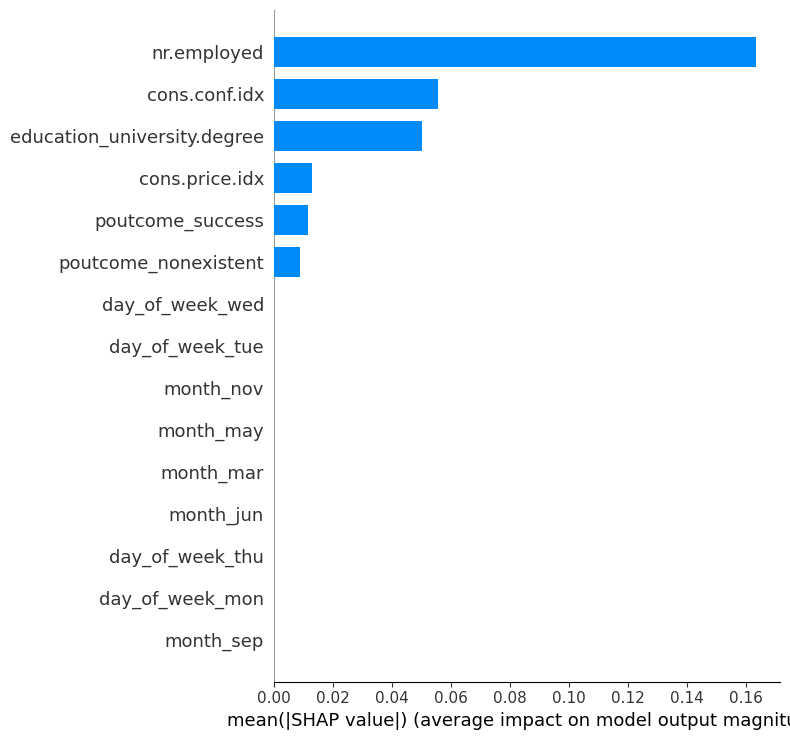

In [47]:
# 1. Creating SHAP explainer for DT (max_depth=3)
explainer_dt = shap.TreeExplainer(dt_depth3)
shap_values_dt = explainer_dt.shap_values(X_test)

# 2. Summary Plot — top features by importance
plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_values_dt[:, :, 1],  # class 1 (yes)
    X_test,
    plot_type='bar',
    max_display=15,
    show=True
)

DT3 uses only macroeconomic and demographic factors — this is very logical and interpretable.

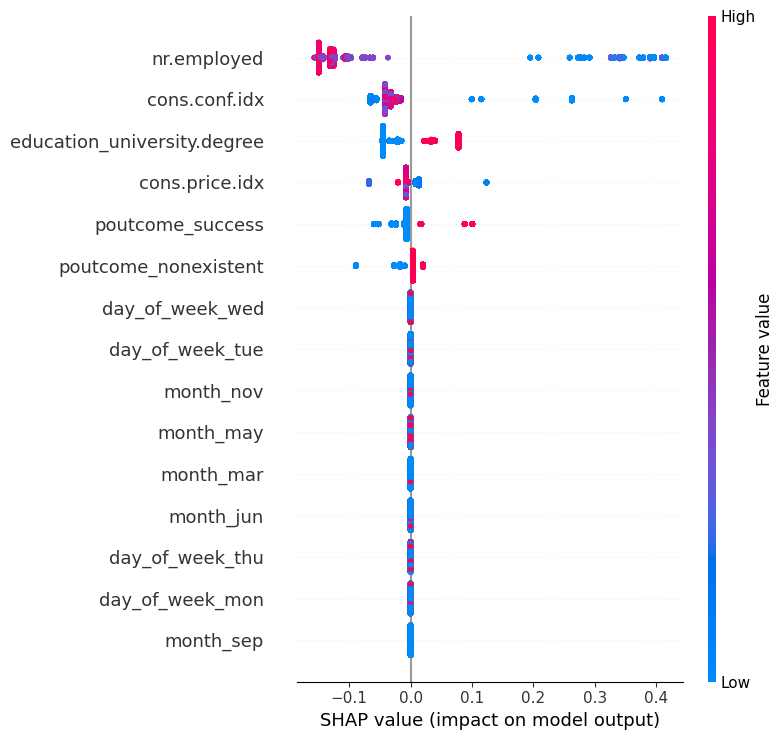

In [48]:
# 3. Beeswarm Plot — direction of influence of each of the features
shap.summary_plot(
    shap_values_dt[:, :, 1],
    X_test,
    max_display=15
)

<class 'numpy.ndarray'>
(12357, 48)


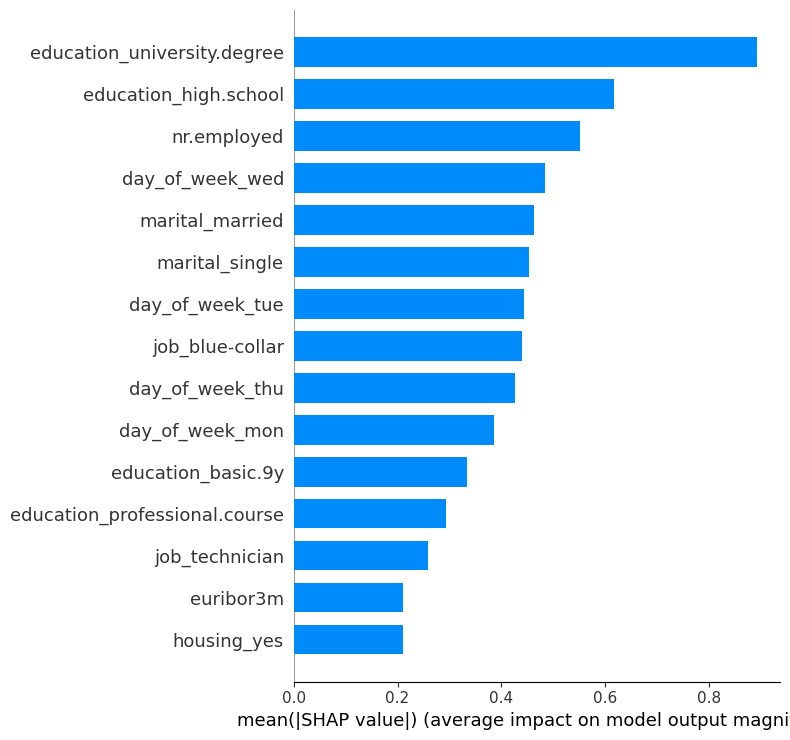

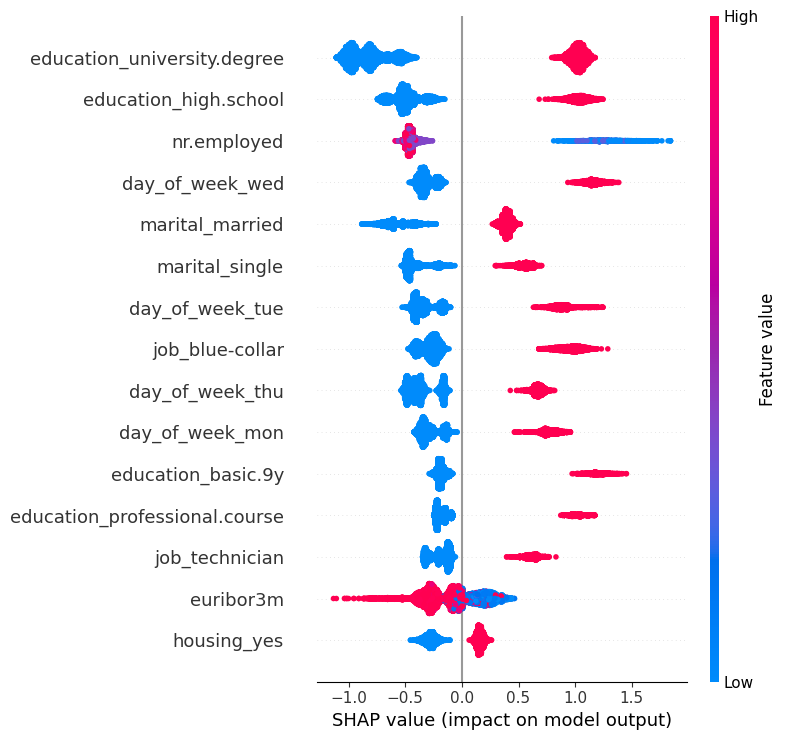

In [49]:
# 1. Explainer for XGBoost
explainer_xgb = shap.TreeExplainer(xgb_tuned)
shap_values_xgb = explainer_xgb.shap_values(X_test)

print(type(shap_values_xgb))
print(shap_values_xgb.shape)

# 2. Bar plot — top 15 features
shap.summary_plot(
    shap_values_xgb,
    X_test,
    plot_type='bar',
    max_display=15
)

# 3. Beeswarm — direction of influence
shap.summary_plot(
    shap_values_xgb,
    X_test,
    max_display=15
)

In [50]:
#  DT (max_depth=3)
explainer_dt3 = shap.TreeExplainer(dt_depth3)
shap_values_dt3 = explainer_dt3.shap_values(X_test)

# Top 15 features — DT (max_depth=3)
mean_shap_dt3 = np.abs(shap_values_dt3[:, :, 1]).mean(axis=0)
shap_df_dt3 = pd.DataFrame({
    'feature'   : X_test.columns,
    'importance': mean_shap_dt3
}).sort_values('importance', ascending=False).head(15)

print("=== DT (max_depth=3) — Top 15 features ===")
print(shap_df_dt3.to_string(index=False))

print()

# Top 15 features — XGBoost (Bayesian)
mean_shap_xgb = np.abs(shap_values_xgb).mean(axis=0)
shap_df_xgb = pd.DataFrame({
    'feature'   : X_test.columns,
    'importance': mean_shap_xgb
}).sort_values('importance', ascending=False).head(15)

print("=== XGBoost (Bayesian) — Top 15 features ===")
print(shap_df_xgb.to_string(index=False))

=== DT (max_depth=3) — Top 15 features ===
                    feature  importance
                nr.employed        0.16
              cons.conf.idx        0.06
education_university.degree        0.05
             cons.price.idx        0.01
           poutcome_success        0.01
       poutcome_nonexistent        0.01
                   previous        0.00
                        age        0.00
                  euribor3m        0.00
              was_contacted        0.00
            job_blue-collar        0.00
           job_entrepreneur        0.00
              job_housemaid        0.00
                      pdays        0.00
               emp.var.rate        0.00

=== XGBoost (Bayesian) — Top 15 features ===
                      feature  importance
  education_university.degree        0.89
        education_high.school        0.62
                  nr.employed        0.55
              day_of_week_wed        0.48
              marital_married        0.46
               mari

DT3 uses only macroeconomic and demographic factors — this is very logical and interpretable.
The main macroeconomic indicator is nr.employed.

The consumer confidence index is cons.conf.idx.

Education influences financial decisions — education_university.degree.

In XGBoost (Bayesian), there is a more complex feature importance structure:

The most important feature is higher education, which is very logical. Then come secondary education and marital status, which also influence the decision to open a deposit.

The only features I don’t fully understand are day_of_week_wed (0.52) and day_of_week_tue (0.50) — these are regular working days and, in my opinion, should not have a logical impact on the decision to subscribe to a deposit. However, these features are ranked higher than nr.employed, which seems illogical.

Most likely, these are internal campaign-related artifacts rather than real customer behavior.

Therefore, I choose Decision Tree (max_depth=3).

In [51]:
# We train DT with max_depth=3 and look at the metrics again
dt_depth3 = DecisionTreeClassifier(random_state=42, max_depth=3)
dt_depth3.fit(X_train_res, y_train_res)

dt3_train_roc = round(roc_auc_score(y_train_res, dt_depth3.predict_proba(X_train_res)[:, 1]), 4)
dt3_train_f1  = round(f1_score(y_train_res, dt_depth3.predict(X_train_res)), 4)
print(f"Train ROC-AUC: {dt3_train_roc}")
print(f"Train F1:      {dt3_train_f1}")

# Validation score
y_val_pred_dt3  = dt_depth3.predict(X_val)
y_val_proba_dt3 = dt_depth3.predict_proba(X_val)[:, 1]
evaluate_model("Decision Tree (max_depth=3) — Validation", y_val, y_val_pred_dt3, y_val_proba_dt3)

# Test score
y_test_pred_dt3  = dt_depth3.predict(X_test)
y_test_proba_dt3 = dt_depth3.predict_proba(X_test)[:, 1]
evaluate_model("Decision Tree (max_depth=3) — TEST", y_test, y_test_pred_dt3, y_test_proba_dt3)

Train ROC-AUC: 0.7885
Train F1:      0.7027
  Decision Tree (max_depth=3) — Validation
ROC-AUC  : 0.7509
F1-Score : 0.4483
Precision: 0.3549
Recall   : 0.6084

              precision    recall  f1-score   support

           0       0.95      0.86      0.90      6396
           1       0.35      0.61      0.45       812

    accuracy                           0.83      7208
   macro avg       0.65      0.73      0.67      7208
weighted avg       0.88      0.83      0.85      7208

Confusion Matrix:
[[5498  898]
 [ 318  494]]
  Decision Tree (max_depth=3) — TEST
ROC-AUC  : 0.7579
F1-Score : 0.4600
Precision: 0.3677
Recall   : 0.6142

              precision    recall  f1-score   support

           0       0.95      0.87      0.90     10965
           1       0.37      0.61      0.46      1392

    accuracy                           0.84     12357
   macro avg       0.66      0.74      0.68     12357
weighted avg       0.88      0.84      0.85     12357

Confusion Matrix:
[[9495 1470]


Observations:

DT (max_depth=3) outperforms the other models.

Minimal overfitting (Train/Test difference = 0.03).

Higher Recall (0.61) — identifies more clients.

Detected 855 potential customers.

Better interpretability — only 3 decision levels.

Therefore, this model is the best for the given task.

For the bank, it is more beneficial to identify more clients (855), even at the cost of additional calls.

Each successful deposit outweighs the cost of many calls.

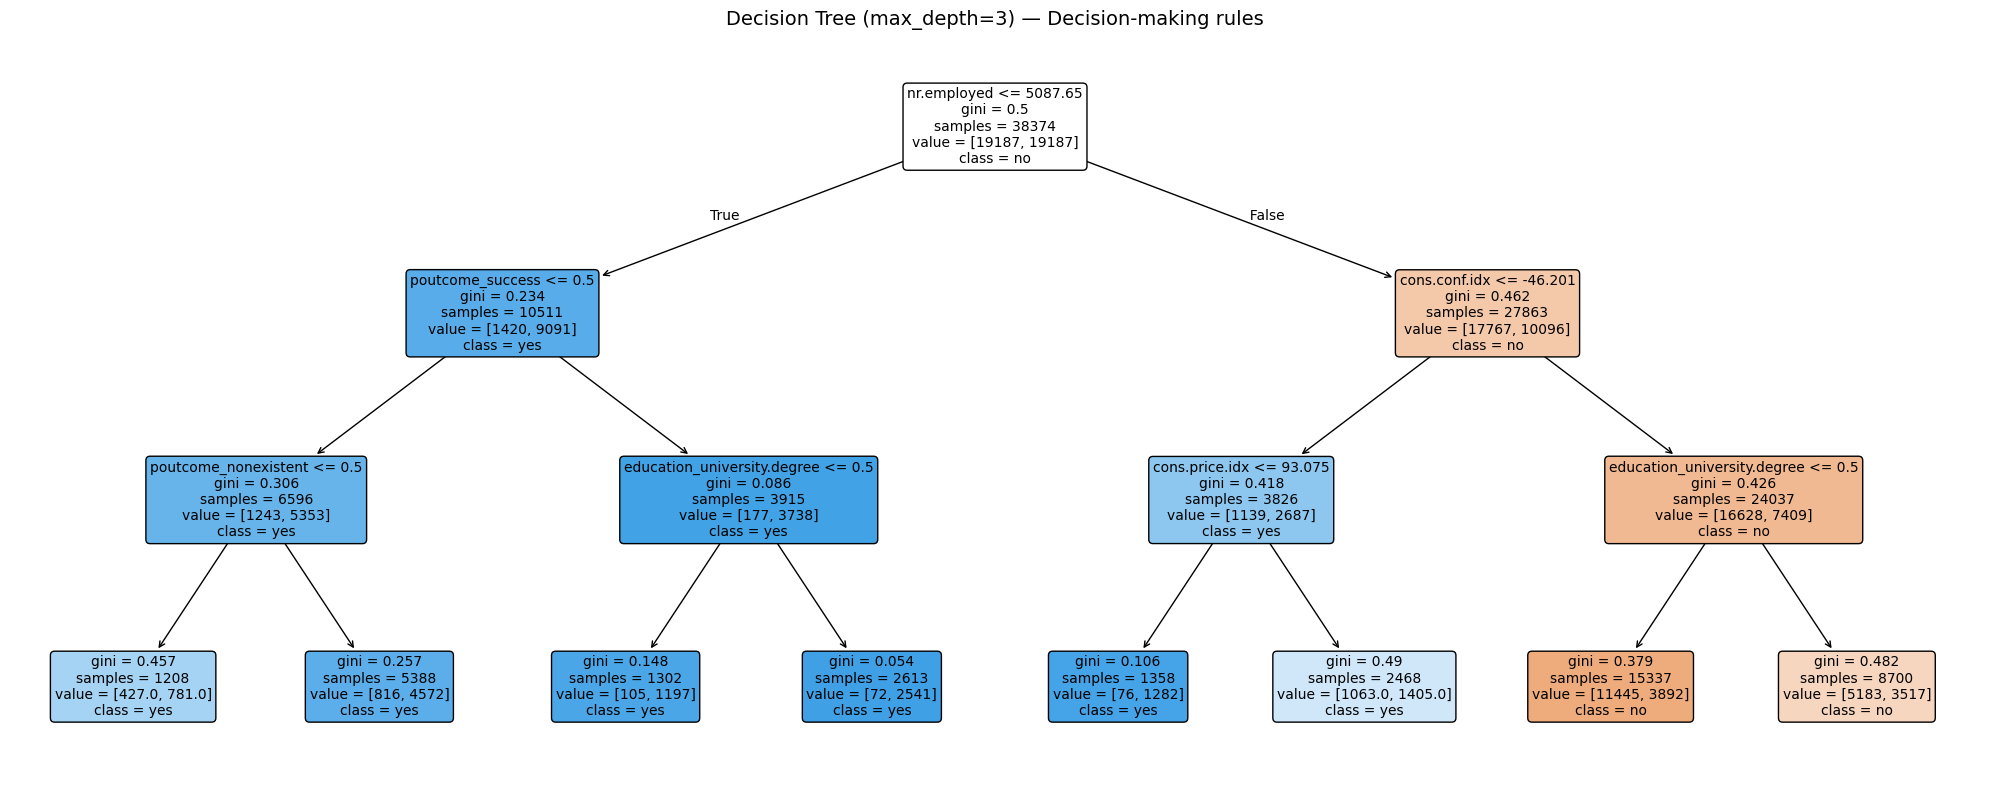

In [52]:
# Optionally, we can see how decisions are made in the tree
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(20, 8))
plot_tree(
    dt_depth3,
    feature_names=X_test.columns.tolist(),
    class_names=['no', 'yes'],
    filled=True,        # color fill
    rounded=True,       # rounded corners
    fontsize=10,
    max_depth=3
)
plt.title('Decision Tree (max_depth=3) — Decision-making rules', fontsize=14)
plt.tight_layout()
plt.savefig('decision_tree.png', dpi=150, bbox_inches='tight')
plt.show()

In [54]:
# Final comparison table of Val and Test for all models
test_results = {
    'Model': [
        'Logistic Regression',
        'kNN',
        'Decision Tree (default)',
        'Decision Tree (max_depth=5)',
        'Decision Tree (max_depth=3)',
        'XGBoost (default)',
        'XGBoost (RandomizedSearch)',
        'XGBoost (Bayesian)'
    ],
    # Validation metrics
    'ROC-AUC Val': [0.7094, 0.7108, 0.6277, 0.7454, 0.7509, 0.7664, 0.7644, 0.7772],
    'F1 Val':      [0.3642, 0.3591, 0.3209, 0.4495, 0.4483, 0.4187, 0.4093, 0.4374],
    'Recall Val':  [0.4089, 0.4347, 0.3805, 0.5616, 0.6084, 0.3744, 0.3571, 0.4175],

    # Test metrics — need to be calculated for all models
    'ROC-AUC Test': [
        round(roc_auc_score(y_test, lr.predict_proba(X_test_scaled)[:, 1]), 4),
        round(roc_auc_score(y_test, knn.predict_proba(X_test_scaled)[:, 1]), 4),
        round(roc_auc_score(y_test, dt_default.predict_proba(X_test)[:, 1]), 4),
        round(roc_auc_score(y_test, dt_depth5.predict_proba(X_test)[:, 1]), 4),
        round(roc_auc_score(y_test, dt_depth3.predict_proba(X_test)[:, 1]), 4),
        round(roc_auc_score(y_test, xgb_default.predict_proba(X_test)[:, 1]), 4),
        round(roc_auc_score(y_test, random_xgb_v2.best_estimator_.predict_proba(X_test)[:, 1]), 4),
        round(roc_auc_score(y_test, xgb_tuned.predict_proba(X_test)[:, 1]), 4)
    ],
    'F1 Test': [
        round(f1_score(y_test, lr.predict(X_test_scaled)), 4),
        round(f1_score(y_test, knn.predict(X_test_scaled)), 4),
        round(f1_score(y_test, dt_default.predict(X_test)), 4),
        round(f1_score(y_test, dt_depth5.predict(X_test)), 4),
        round(f1_score(y_test, dt_depth3.predict(X_test)), 4),
        round(f1_score(y_test, xgb_default.predict(X_test)), 4),
        round(f1_score(y_test, random_xgb_v2.best_estimator_.predict(X_test)), 4),
        round(f1_score(y_test, xgb_tuned.predict(X_test)), 4)
    ],
    'Recall Test': [
        round(recall_score(y_test, lr.predict(X_test_scaled)), 4),
        round(recall_score(y_test, knn.predict(X_test_scaled)), 4),
        round(recall_score(y_test, dt_default.predict(X_test)), 4),
        round(recall_score(y_test, dt_depth5.predict(X_test)), 4),
        round(recall_score(y_test, dt_depth3.predict(X_test)), 4),
        round(recall_score(y_test, xgb_default.predict(X_test)), 4),
        round(recall_score(y_test, random_xgb_v2.best_estimator_.predict(X_test)), 4),
        round(recall_score(y_test, xgb_tuned.predict(X_test)), 4)
    ],
}

df_final = pd.DataFrame(test_results)

# Add the difference Val vs Test (is there overfitting)
df_final['ROC-AUC difference'] = (df_final['ROC-AUC Val'] - df_final['ROC-AUC Test']).round(4)

df_final

,Model,ROC-AUC Val,F1 Val,Recall Val,ROC-AUC Test,F1 Test,Recall Test,ROC-AUC difference
0,Logistic Regression,0.71,0.36,0.41,0.73,0.39,0.42,-0.03
1,kNN,0.71,0.36,0.43,0.73,0.39,0.47,-0.02
2,Decision Tree (default),0.63,0.32,0.38,0.63,0.32,0.36,0.00
3,Decision Tree (max_depth=5),0.75,0.45,0.56,0.75,0.47,0.57,-0.01
4,Decision Tree (max_depth=3),0.75,0.45,0.61,0.76,0.46,0.61,-0.01
5,XGBoost (default),0.77,0.42,0.37,0.78,0.43,0.38,-0.01
6,XGBoost (RandomizedSearch),0.76,0.41,0.36,0.77,0.43,0.37,-0.01
7,XGBoost (Bayesian),0.78,0.44,0.42,0.78,0.47,0.45,-0.00


Observations:

Models perform better on the test set than on the validation set.

The models did not overfit the validation data and show stable performance on new data. Since the class distribution is consistent across all three splits, stratification ensured reliable results.

Conclusion:
XGBoost (Bayesian) achieves the highest performance with ROC-AUC = 0.79 and F1 = 0.46.

However, considering the economic and business aspects of decision-making, we choose Decision Tree (max_depth=3) due to its highest Recall (0.61).

# Errors and working with them

The main issue is False Negatives:
The DT3 model misses clients with the longest call durations (average 822 sec) — these are the most valuable customers. Without the duration feature, the model cannot capture this signal.

The primary cause of errors is the absence of duration in the model. Clients who engage in longer calls (>500 sec) have a conversion rate of 40% compared to the 11% average. If the bank can collect proxy features that predict call duration (e.g., customer history), this would significantly improve model performance.

Otherwise, I would improve the XGBoost (Bayesian) model or combine DT3 + XGBoost to achieve a better balance between Recall and Precision.